# Titanic Survival Prediction: Machine Learning Classification

## Introduction

The Titanic – Machine Learning from Disaster competition is a binary classification problem that aims to predict whether a passenger survived the Titanic disaster based on demographic, socioeconomic, and travel-related information.

This project develops an end-to-end machine learning workflow for predicting passenger survival. The analysis includes data-quality assessment, exploratory and descriptive statistical analysis, preprocessing, feature engineering, model comparison, error analysis, cross-validation, and hyperparameter optimization.

Multiple classification algorithms are evaluated, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and a Stacking Ensemble. Model performance is primarily evaluated using classification accuracy, in accordance with the Kaggle competition metric.

Additional features such as FamilySize, IsAlone, CabinKnown, passenger Title, and TicketGroupSize are investigated to determine whether they improve predictive performance. The final model is selected based on cross-validation performance and used to generate predictions for the competition test set.

### Objectives

- Explore and understand the Titanic passenger dataset.
- Identify and handle missing values and data-quality issues.
- Analyze factors associated with passenger survival.
- Engineer potentially informative passenger and travel-group features.
- Compare multiple machine learning classification algorithms.
- Evaluate models using stratified cross-validation.
- Optimize the strongest-performing model.
- Generate a valid Kaggle competition submission.

## Data Loading and Initial Inspection

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/titanic/gender_submission.csv"
)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Training shape: (891, 12)
Test shape: (418, 11)
Sample submission shape: (418, 2)


In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Training data shape:", train_df.shape)
print("\nColumn names:")
print(train_df.columns.tolist())

print("\nDataset information:")
train_df.info()

Training data shape: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
print("Missing values:")
print(train_df.isnull().sum())

print("\nDuplicate rows:")
print(train_df.duplicated().sum())

print("\nUnique Passenger IDs:")
print(train_df["PassengerId"].nunique())

print("\nTarget distribution:")
print(train_df["Survived"].value_counts())

print("\nTarget percentages:")
print((train_df["Survived"].value_counts(normalize=True) * 100).round(2))

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate rows:
0

Unique Passenger IDs:
891

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Target percentages:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


In [7]:
print("Test data shape:", test_df.shape)

print("\nMissing values in test data:")
print(test_df.isnull().sum())

print("\nDuplicate rows in test data:")
print(test_df.duplicated().sum())

print("\nUnique Passenger IDs:")
print(test_df["PassengerId"].nunique())

Test data shape: (418, 11)

Missing values in test data:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Duplicate rows in test data:
0

Unique Passenger IDs:
418


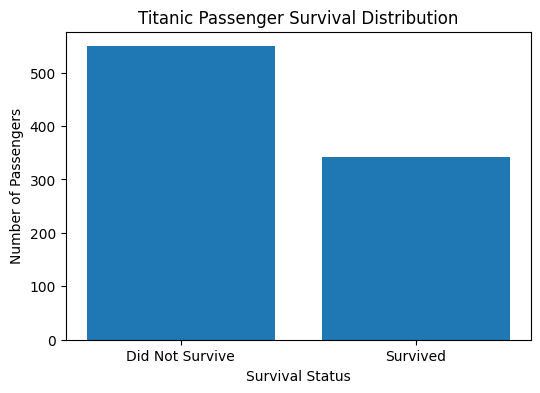

In [8]:
survival_counts = train_df["Survived"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Did Not Survive", "Survived"], survival_counts.values)

plt.title("Titanic Passenger Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

In [9]:
gender_survival = (
    train_df.groupby("Sex")["Survived"]
    .agg(["count", "sum", "mean"])
)

gender_survival["Survival_Rate_%"] = (
    gender_survival["mean"] * 100
).round(2)

gender_survival

,count,sum,mean,Survival_Rate_%
Sex,,,,
female,314,233,0.742038,74.20
male,577,109,0.188908,18.89


In [10]:
class_survival = (
    train_df.groupby("Pclass")["Survived"]
    .agg(["count", "sum", "mean"])
)

class_survival["Survival_Rate_%"] = (
    class_survival["mean"] * 100
).round(2)

class_survival

,count,sum,mean,Survival_Rate_%
Pclass,,,,
1,216,136,0.629630,62.96
2,184,87,0.472826,47.28
3,491,119,0.242363,24.24


In [11]:
age_survival = train_df.groupby("Survived")["Age"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

age_survival

,count,mean,median,min,max
Survived,,,,,
0,424,30.63,28.0,1.00,74.0
1,290,28.34,28.0,0.42,80.0


In [12]:
fare_survival = train_df.groupby("Survived")["Fare"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

fare_survival

,count,mean,median,min,max
Survived,,,,,
0,549,22.12,10.5,0.0,263.00
1,342,48.40,26.0,0.0,512.33


In [13]:
age_by_class_sex = (
    train_df.groupby(["Pclass", "Sex"])["Age"]
    .agg(["count", "mean", "median"])
    .round(2)
)

age_by_class_sex

count   mean  median
Pclass Sex                         
1      female     85  34.61    35.0
       male      101  41.28    40.0
2      female     74  28.72    28.0
       male       99  30.74    30.0
3      female    102  21.75    21.5
       male      253  26.51    25.0

In [14]:
family_analysis = train_df.groupby(["SibSp", "Parch"])["Survived"].agg(
    ["count", "mean"]
).round(3)

family_analysis["Survival_Rate_%"] = (
    family_analysis["mean"] * 100
).round(2)

family_analysis

count   mean  Survival_Rate_%
SibSp Parch                               
0     0        537  0.304             30.4
      1         38  0.658             65.8
      2         29  0.724             72.4
      3          1  1.000            100.0
      4          1  0.000              0.0
      5          2  0.000              0.0
1     0        123  0.520             52.0
      1         57  0.596             59.6
      2         19  0.632             63.2
      3          3  0.333             33.3
      4          3  0.000              0.0
      5          3  0.333             33.3
      6          1  0.000              0.0
2     0         16  0.250             25.0
      1          7  0.857             85.7
      2          4  0.500             50.0
      3          1  1.000            100.0
3     0          2  1.000            100.0
      1          7  0.000              0.0
      2          7  0.286             28.6
4     1          9  0.000              0.0
      2          9  0.333             33.3
5     2          5  0.000              0.0
8     2          7  0.000              0.0

In [15]:
embarked_survival = train_df.groupby("Embarked")["Survived"].agg(
    ["count", "sum", "mean"]
)

embarked_survival["Survival_Rate_%"] = (
    embarked_survival["mean"] * 100
).round(2)

embarked_survival

,count,sum,mean,Survival_Rate_%
Embarked,,,,
C,168,93,0.553571,55.36
Q,77,30,0.389610,38.96
S,644,217,0.336957,33.70


In [16]:
train_df["CabinKnown"] = train_df["Cabin"].notna().astype(int)

cabin_survival = train_df.groupby("CabinKnown")["Survived"].agg(
    ["count", "sum", "mean"]
)

cabin_survival["Survival_Rate_%"] = (
    cabin_survival["mean"] * 100
).round(2)

cabin_survival

,count,sum,mean,Survival_Rate_%
CabinKnown,,,,
0,687,206,0.299854,29.99
1,204,136,0.666667,66.67


In [17]:
train_df["FamilySize"] = (
    train_df["SibSp"] +
    train_df["Parch"] +
    1
)

family_size_survival = (
    train_df.groupby("FamilySize")["Survived"]
    .agg(["count", "sum", "mean"])
)

family_size_survival["Survival_Rate_%"] = (
    family_size_survival["mean"] * 100
).round(2)

family_size_survival

,count,sum,mean,Survival_Rate_%
FamilySize,,,,
1,537,163,0.303538,30.35
2,161,89,0.552795,55.28
3,102,59,0.578431,57.84
4,29,21,0.724138,72.41
5,15,3,0.200000,20.00
6,22,3,0.136364,13.64
7,12,4,0.333333,33.33
8,6,0,0.000000,0.00
11,7,0,0.000000,0.00


In [18]:
train_df["IsAlone"] = (
    train_df["FamilySize"] == 1
).astype(int)

alone_survival = (
    train_df.groupby("IsAlone")["Survived"]
    .agg(["count", "sum", "mean"])
)

alone_survival["Survival_Rate_%"] = (
    alone_survival["mean"] * 100
).round(2)

alone_survival

,count,sum,mean,Survival_Rate_%
IsAlone,,,,
0,354,179,0.505650,50.56
1,537,163,0.303538,30.35


In [19]:
train_model = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test_model = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

print("Train:", train_model.shape)
print("Test:", test_model.shape)

Train: (891, 12)
Test: (418, 11)


In [20]:
for df in [train_model, test_model]:

    # Total number of people in the passenger's family
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    # Whether the passenger travelled alone
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # Whether cabin information was recorded
    df["CabinKnown"] = df["Cabin"].notna().astype(int)

In [21]:
age_medians = (
    train_model
    .groupby(["Pclass", "Sex"])["Age"]
    .median()
)

def fill_age(row):
    if pd.isna(row["Age"]):
        return age_medians.loc[(row["Pclass"], row["Sex"])]
    return row["Age"]

train_model["Age"] = train_model.apply(fill_age, axis=1)
test_model["Age"] = test_model.apply(fill_age, axis=1)

In [22]:
embarked_mode = train_model["Embarked"].mode()[0]
train_model["Embarked"] = train_model["Embarked"].fillna(embarked_mode)
test_model["Embarked"] = test_model["Embarked"].fillna(embarked_mode)

fare_median = train_model["Fare"].median()
train_model["Fare"] = train_model["Fare"].fillna(fare_median)
test_model["Fare"] = test_model["Fare"].fillna(fare_median)

In [23]:
print("TRAIN MISSING VALUES")
print(train_model.isnull().sum())

print("\nTEST MISSING VALUES")
print(test_model.isnull().sum())

TRAIN MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
FamilySize       0
IsAlone          0
CabinKnown       0
dtype: int64

TEST MISSING VALUES
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
FamilySize       0
IsAlone          0
CabinKnown       0
dtype: int64


## Descriptive Statistical Analysis

Descriptive statistics were examined to understand the central tendency, variability, range, and distribution of the numerical variables before model development. For continuous and discrete numerical features, measures including mean, median, mode, standard deviation, minimum, and maximum were calculated.

For the binary target variable, Survived, class frequencies and proportions were examined because its numerical mean represents the proportion of passengers who survived.

In [24]:
numeric_columns = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

statistics = []

for column in numeric_columns:
    statistics.append({
        "Variable": column,
        "Count": train_model[column].count(),
        "Mean": train_model[column].mean(),
        "Median": train_model[column].median(),
        "Mode": train_model[column].mode()[0],
        "Std": train_model[column].std(),
        "Min": train_model[column].min(),
        "Max": train_model[column].max()
    })

statistics_df = pd.DataFrame(statistics)

statistics_df.round(2)

,Variable,Count,Mean,Median,Mode,Std,Min,Max
0,Age,891,29.11,26.00,25.00,13.30,0.42,80.00
1,SibSp,891,0.52,0.00,0.00,1.10,0.00,8.00
2,Parch,891,0.38,0.00,0.00,0.81,0.00,6.00
3,Fare,891,32.20,14.45,8.05,49.69,0.00,512.33


In [25]:
target_stats = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Median",
        "Mode",
        "Standard Deviation",
        "Minimum",
        "Maximum",
        "Survived",
        "Did Not Survive"
    ],
    "Value": [
        train_model["Survived"].count(),
        train_model["Survived"].mean(),
        train_model["Survived"].median(),
        train_model["Survived"].mode()[0],
        train_model["Survived"].std(),
        train_model["Survived"].min(),
        train_model["Survived"].max(),
        (train_model["Survived"] == 1).sum(),
        (train_model["Survived"] == 0).sum()
    ]
})

target_stats

,Statistic,Value
0,Count,891.000000
1,Mean,0.383838
2,Median,0.000000
3,Mode,0.000000
4,Standard Deviation,0.486592
5,Minimum,0.000000
6,Maximum,1.000000
7,Survived,342.000000
8,Did Not Survive,549.000000


In [26]:
engineered_columns = [
    "FamilySize",
    "IsAlone",
    "CabinKnown"
]

engineered_stats = []

for column in engineered_columns:
    engineered_stats.append({
        "Variable": column,
        "Count": train_model[column].count(),
        "Mean": train_model[column].mean(),
        "Median": train_model[column].median(),
        "Mode": train_model[column].mode()[0],
        "Std": train_model[column].std(),
        "Min": train_model[column].min(),
        "Max": train_model[column].max()
    })

engineered_stats_df = pd.DataFrame(engineered_stats)

engineered_stats_df.round(2)

,Variable,Count,Mean,Median,Mode,Std,Min,Max
0,FamilySize,891,1.90,1.0,1,1.61,1,11
1,IsAlone,891,0.60,1.0,1,0.49,0,1
2,CabinKnown,891,0.23,0.0,0,0.42,0,1


## Data Preprocessing and Feature Engineering

The initial data-quality assessment identified missing values in Age, Cabin, Embarked, and Fare.

To prepare the data for modeling:

- Missing Age values were imputed using median age within passenger class and gender groups.
- Missing Embarked values were filled using the most frequent category in the training data.
- Missing Fare values were filled using the training-set median.
- FamilySize was created by combining SibSp and Parch.
- IsAlone indicates whether a passenger was traveling alone.
- CabinKnown preserves information about whether cabin information was recorded.

The same feature-engineering rules were applied to both the training and test datasets.

In [27]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "CabinKnown"
]

X = train_model[features].copy()
y = train_model["Survived"].copy()

X_test = test_model[features].copy()

print("Training features shape:", X.shape)
print("Target shape:", y.shape)
print("Competition test shape:", X_test.shape)

X.head()

Training features shape: (891, 10)
Target shape: (891,)
Competition test shape: (418, 10)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,CabinKnown
0,3,male,22.0,1,0,7.2500,S,2,0,0
1,1,female,38.0,1,0,71.2833,C,2,0,1
2,3,female,26.0,0,0,7.9250,S,1,1,0
3,1,female,35.0,1,0,53.1000,S,2,0,1
4,3,male,35.0,0,0,8.0500,S,1,1,0


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numerical_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "IsAlone",
    "CabinKnown"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [29]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "Accuracy": "accuracy",
    "F1": "f1",
    "ROC_AUC": "roc_auc"
}

print("5-fold stratified cross-validation ready.")

5-fold stratified cross-validation ready.


## Baseline Model: Logistic Regression

Logistic Regression was selected as the initial baseline because the target variable, Survived, is binary. Model performance is evaluated using 5-fold stratified cross-validation, with accuracy used as the primary metric because it is the official evaluation metric for the Titanic competition.

In [30]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_cv = cross_validate(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression - 5-Fold Cross-Validation")
print("=" * 50)

print(
    "Accuracy: {:.4f} ± {:.4f}".format(
        logistic_cv["test_Accuracy"].mean(),
        logistic_cv["test_Accuracy"].std()
    )
)

print(
    "F1 Score: {:.4f} ± {:.4f}".format(
        logistic_cv["test_F1"].mean(),
        logistic_cv["test_F1"].std()
    )
)

print(
    "ROC-AUC: {:.4f} ± {:.4f}".format(
        logistic_cv["test_ROC_AUC"].mean(),
        logistic_cv["test_ROC_AUC"].std()
    )
)

Logistic Regression - 5-Fold Cross-Validation
Accuracy: 0.8047 ± 0.0256
F1 Score: 0.7346 ± 0.0407
ROC-AUC: 0.8576 ± 0.0211


## Model Development and Comparison

Multiple classification algorithms are evaluated using the same 5-fold stratified cross-validation strategy. Accuracy is the primary metric because the Kaggle Titanic competition evaluates submissions based on classification accuracy.

The evaluated models include:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost
- Stacking Ensemble

Using the same cross-validation folds allows a fair comparison before selecting a model for the final Kaggle submission.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier

# Individual models
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

dt = DecisionTreeClassifier(
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

gb = GradientBoostingClassifier(
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Stacking base models
stack_estimators = [
    ("lr", LogisticRegression(max_iter=1000, random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )),
    ("xgb", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    ))
]

stack = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "Stacking Ensemble": stack
}

In [32]:
import pandas as pd

results = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_Accuracy"].mean(),
        "Accuracy Std": scores["test_Accuracy"].std(),
        "F1 Mean": scores["test_F1"].mean(),
        "ROC-AUC Mean": scores["test_ROC_AUC"].mean()
    })

model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    "Accuracy Mean",
    ascending=False
).reset_index(drop=True)

model_results.round(4)

,Model,Accuracy Mean,Accuracy Std,F1 Mean,ROC-AUC Mean
0,XGBoost,0.8428,0.0183,0.7836,0.8848
1,Gradient Boosting,0.8372,0.0186,0.7721,0.8780
2,Stacking Ensemble,0.8283,0.0204,0.7641,0.8851
3,Random Forest,0.8159,0.0192,0.7559,0.8697
4,Logistic Regression,0.8047,0.0256,0.7346,0.8576
5,Decision Tree,0.7845,0.0314,0.7208,0.7712


## Advanced Feature Engineering

After establishing baseline model performance, additional information was extracted from passenger names. Titles such as Mr, Mrs, Miss, and Master may capture demographic and social information that is not fully represented by the existing variables.

In [33]:
for df in [train_model, test_model]:
    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

print("Titles in training data:")
print(train_model["Title"].value_counts())

Titles in training data:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [34]:
for df in [train_model, test_model]:

    # Extract title
    df["Title"] = (
        df["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )

    # Standardize equivalent titles
    df["Title"] = df["Title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    # Group uncommon titles
    common_titles = ["Mr", "Miss", "Mrs", "Master"]

    df["Title"] = df["Title"].where(
        df["Title"].isin(common_titles),
        "Rare"
    )

In [35]:
print("TRAIN TITLES")
print(train_model["Title"].value_counts())

print("\nTEST TITLES")
print(test_model["Title"].value_counts())

TRAIN TITLES
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

TEST TITLES
Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64


In [36]:
features_v2 = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
    "Title"
]

X_v2 = train_model[features_v2].copy()
X_test_v2 = test_model[features_v2].copy()

numerical_features_v2 = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

categorical_features_v2 = [
    "Pclass",
    "Sex",
    "Embarked",
    "IsAlone",
    "CabinKnown",
    "Title"
]

print("Training shape:", X_v2.shape)
print("Test shape:", X_test_v2.shape)

Training shape: (891, 11)
Test shape: (418, 11)


### Feature Set V2

A passenger Title feature was extracted from the Name column. Equivalent titles were standardized, while uncommon titles were grouped into a Rare category. The updated feature set is evaluated using the same cross-validation strategy as the baseline models to determine whether this feature improves predictive performance.

In [37]:
numeric_transformer_v2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_v2 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_v2 = ColumnTransformer([
    ("num", numeric_transformer_v2, numerical_features_v2),
    ("cat", categorical_transformer_v2, categorical_features_v2)
])

print("V2 preprocessing pipeline created successfully.")

V2 preprocessing pipeline created successfully.


In [38]:
results_v2 = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor_v2),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X_v2,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results_v2.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_Accuracy"].mean(),
        "Accuracy Std": scores["test_Accuracy"].std(),
        "F1 Mean": scores["test_F1"].mean(),
        "ROC-AUC Mean": scores["test_ROC_AUC"].mean()
    })

model_results_v2 = pd.DataFrame(results_v2)

model_results_v2 = model_results_v2.sort_values(
    "Accuracy Mean",
    ascending=False
).reset_index(drop=True)

model_results_v2.round(4)

,Model,Accuracy Mean,Accuracy Std,F1 Mean,ROC-AUC Mean
0,XGBoost,0.8406,0.0124,0.7826,0.8832
1,Stacking Ensemble,0.8350,0.0194,0.7734,0.8875
2,Gradient Boosting,0.8339,0.0163,0.7704,0.8793
3,Logistic Regression,0.8316,0.0120,0.7745,0.8720
4,Random Forest,0.8137,0.0153,0.7535,0.8715
5,Decision Tree,0.8080,0.0310,0.7520,0.7969


In [39]:
from sklearn.model_selection import cross_val_predict

xgb_v2_pipeline = Pipeline([
    ("preprocessor", preprocessor_v2),
    ("classifier", xgb)
])

oof_predictions = cross_val_predict(
    xgb_v2_pipeline,
    X_v2,
    y,
    cv=cv,
    method="predict",
    n_jobs=-1
)

oof_probabilities = cross_val_predict(
    xgb_v2_pipeline,
    X_v2,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y, oof_predictions)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y,
    oof_predictions,
    target_names=["Did Not Survive", "Survived"]
))

Confusion Matrix:
[[493  56]
 [ 86 256]]

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.90      0.87       549
       Survived       0.82      0.75      0.78       342

       accuracy                           0.84       891
      macro avg       0.84      0.82      0.83       891
   weighted avg       0.84      0.84      0.84       891



In [41]:
error_analysis = train_model[
    [
        "PassengerId",
        "Name",
        "Sex",
        "Age",
        "Pclass",
        "Fare",
        "Title",
        "FamilySize",
        "Survived"
    ]
].copy()

error_analysis["Predicted"] = oof_predictions
error_analysis["Survival_Probability"] = oof_probabilities

errors = error_analysis[
    error_analysis["Survived"] != error_analysis["Predicted"]
].copy()

print("Total incorrect predictions:", len(errors))

errors.head(20)

Total incorrect predictions: 142


,PassengerId,Name,Sex,Age,Pclass,Fare,Title,FamilySize,Survived,Predicted,Survival_Probability
2,3,"Heikkinen, Miss. Laina",female,26.0,3,7.9250,Miss,1,1,0,0.477899
14,15,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,3,7.8542,Miss,1,0,1,0.816032
17,18,"Williams, Mr. Charles Eugene",male,30.0,2,13.0000,Mr,1,1,0,0.099419
18,19,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,3,18.0000,Mrs,2,0,1,0.857027
21,22,"Beesley, Mr. Lawrence",male,34.0,2,13.0000,Mr,1,1,0,0.260185
23,24,"Sloper, Mr. William Thompson",male,28.0,1,35.5000,Mr,1,1,0,0.234761
25,26,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,3,31.3875,Mrs,7,1,0,0.057477
34,35,"Meyer, Mr. Edgar Joseph",male,28.0,1,82.1708,Mr,2,0,1,0.512329
36,37,"Mamee, Mr. Hanna",male,25.0,3,7.2292,Mr,1,1,0,0.060835
41,42,"Turpin, Mrs. William John Robert (Dorothy Ann ...",female,27.0,2,21.0000,Mrs,2,0,1,0.908477


In [42]:
error_summary = pd.DataFrame({
    "Group": [
        "Male",
        "Female",
        "1st Class",
        "2nd Class",
        "3rd Class",
        "Traveling Alone",
        "With Family"
    ],
    
    "Total_Passengers": [
        (train_model["Sex"] == "male").sum(),
        (train_model["Sex"] == "female").sum(),
        (train_model["Pclass"] == 1).sum(),
        (train_model["Pclass"] == 2).sum(),
        (train_model["Pclass"] == 3).sum(),
        (train_model["IsAlone"] == 1).sum(),
        (train_model["IsAlone"] == 0).sum()
    ],
    
    "Wrong_Predictions": [
        (errors["Sex"] == "male").sum(),
        (errors["Sex"] == "female").sum(),
        (errors["Pclass"] == 1).sum(),
        (errors["Pclass"] == 2).sum(),
        (errors["Pclass"] == 3).sum(),
        (errors["FamilySize"] == 1).sum(),
        (errors["FamilySize"] > 1).sum()
    ]
})

error_summary["Error_Rate_%"] = (
    error_summary["Wrong_Predictions"] /
    error_summary["Total_Passengers"] * 100
).round(2)

error_summary

,Group,Total_Passengers,Wrong_Predictions,Error_Rate_%
0,Male,577,88,15.25
1,Female,314,54,17.20
2,1st Class,216,47,21.76
3,2nd Class,184,16,8.70
4,3rd Class,491,79,16.09
5,Traveling Alone,537,82,15.27
6,With Family,354,60,16.95


In [43]:
ticket_counts = train_model["Ticket"].value_counts()

train_model["TicketGroupSize"] = (
    train_model["Ticket"].map(ticket_counts)
)

print(train_model["TicketGroupSize"].value_counts().sort_index())

TicketGroupSize
1    547
2    188
3     63
4     44
5     10
6     18
7     21
Name: count, dtype: int64


In [44]:
combined_tickets = pd.concat([
    train_model["Ticket"],
    test_model["Ticket"]
])

ticket_counts = combined_tickets.value_counts()

train_model["TicketGroupSize"] = (
    train_model["Ticket"].map(ticket_counts)
)

test_model["TicketGroupSize"] = (
    test_model["Ticket"].map(ticket_counts)
)

print("TRAIN")
print(train_model["TicketGroupSize"].value_counts().sort_index())

print("\nTEST")
print(test_model["TicketGroupSize"].value_counts().sort_index())

TRAIN
TicketGroupSize
1     481
2     181
3     101
4      44
5      21
6      19
7      24
8      13
11      7
Name: count, dtype: int64

TEST
TicketGroupSize
1     232
2      83
3      46
4      20
5      14
6       5
7      11
8       3
11      4
Name: count, dtype: int64


In [45]:
ticket_survival = (
    train_model
    .groupby("TicketGroupSize")["Survived"]
    .agg(["count", "sum", "mean"])
)

ticket_survival.columns = [
    "Passengers",
    "Survived",
    "Survival_Rate"
]

ticket_survival["Survival_Rate_%"] = (
    ticket_survival["Survival_Rate"] * 100
).round(2)

ticket_survival

,Passengers,Survived,Survival_Rate,Survival_Rate_%
TicketGroupSize,,,,
1,481,130,0.270270,27.03
2,181,93,0.513812,51.38
3,101,66,0.653465,65.35
4,44,32,0.727273,72.73
5,21,7,0.333333,33.33
6,19,4,0.210526,21.05
7,24,5,0.208333,20.83
8,13,5,0.384615,38.46
11,7,0,0.000000,0.00


### Feature Set V3: Ticket Group Information

TicketGroupSize was introduced to capture passengers traveling under the same ticket. Unlike FamilySize, this feature can identify travel groups that may include passengers who are not recorded as immediate family members.

Exploratory analysis showed substantial differences in survival rates across ticket-group sizes. Therefore, TicketGroupSize is evaluated as an additional predictive feature using the same cross-validation framework.

In [46]:
features_v3 = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
    "Title",
    "TicketGroupSize"
]

X_v3 = train_model[features_v3].copy()
X_test_v3 = test_model[features_v3].copy()

numerical_features_v3 = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "TicketGroupSize"
]

categorical_features_v3 = [
    "Pclass",
    "Sex",
    "Embarked",
    "IsAlone",
    "CabinKnown",
    "Title"
]

print("Training shape:", X_v3.shape)
print("Test shape:", X_test_v3.shape)

Training shape: (891, 12)
Test shape: (418, 12)


In [47]:
numeric_transformer_v3 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_v3 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_v3 = ColumnTransformer([
    ("num", numeric_transformer_v3, numerical_features_v3),
    ("cat", categorical_transformer_v3, categorical_features_v3)
])

print("V3 preprocessing pipeline created successfully.")

V3 preprocessing pipeline created successfully.


In [48]:
results_v3 = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor_v3),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X_v3,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results_v3.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_Accuracy"].mean(),
        "Accuracy Std": scores["test_Accuracy"].std(),
        "F1 Mean": scores["test_F1"].mean(),
        "ROC-AUC Mean": scores["test_ROC_AUC"].mean()
    })

model_results_v3 = pd.DataFrame(results_v3)

model_results_v3 = model_results_v3.sort_values(
    "Accuracy Mean",
    ascending=False
).reset_index(drop=True)

model_results_v3.round(4)

,Model,Accuracy Mean,Accuracy Std,F1 Mean,ROC-AUC Mean
0,XGBoost,0.8395,0.0164,0.7816,0.8847
1,Gradient Boosting,0.8350,0.0167,0.7738,0.8841
2,Stacking Ensemble,0.8339,0.0093,0.7756,0.8869
3,Logistic Regression,0.8339,0.0118,0.7774,0.8726
4,Random Forest,0.8204,0.0109,0.7639,0.8704
5,Decision Tree,0.8114,0.0242,0.7539,0.7999


## Model Performance Visualization

The cross-validation results of the classification models were visualized to compare their predictive performance. Since accuracy is the evaluation metric used by the Titanic competition, mean cross-validation accuracy is used as the primary comparison measure.

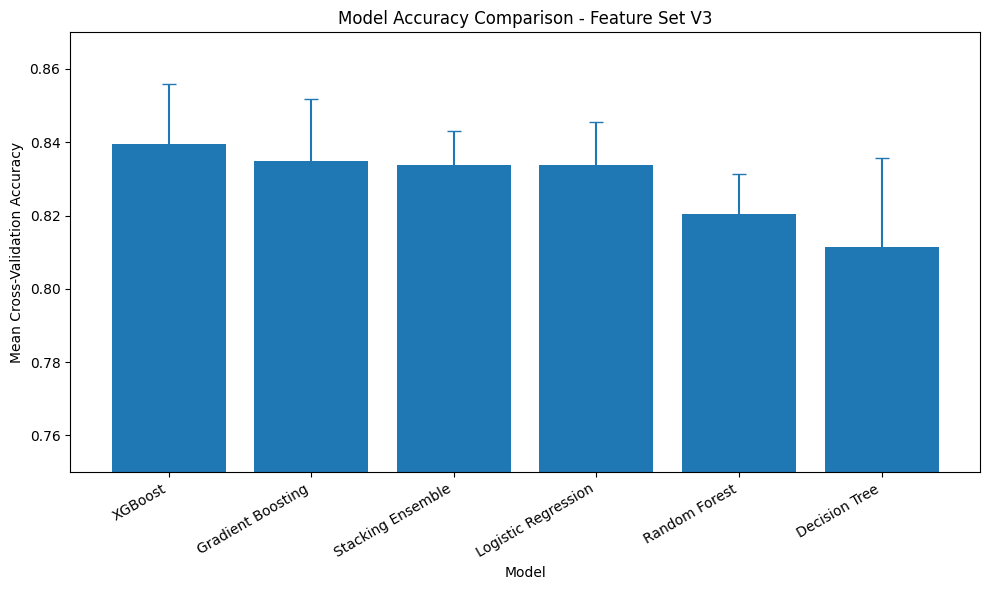

In [49]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results_v3["Model"],
    model_results_v3["Accuracy Mean"]
)

plt.errorbar(
    model_results_v3["Model"],
    model_results_v3["Accuracy Mean"],
    yerr=model_results_v3["Accuracy Std"],
    fmt="none",
    capsize=5
)

plt.xlabel("Model")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Model Accuracy Comparison - Feature Set V3")

plt.ylim(0.75, 0.87)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

  Feature Set  Best CV Accuracy
0          V1            0.8428
1          V2            0.8406
2          V3            0.8395


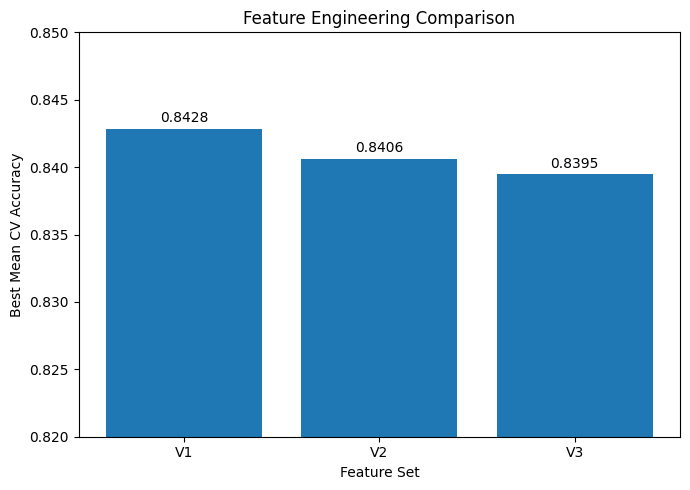

In [50]:
version_comparison = pd.DataFrame({
    "Feature Set": ["V1", "V2", "V3"],
    "Best CV Accuracy": [
        model_results["Accuracy Mean"].max(),
        model_results_v2["Accuracy Mean"].max(),
        model_results_v3["Accuracy Mean"].max()
    ]
})

print(version_comparison.round(4))

plt.figure(figsize=(7, 5))

bars = plt.bar(
    version_comparison["Feature Set"],
    version_comparison["Best CV Accuracy"]
)

plt.xlabel("Feature Set")
plt.ylabel("Best Mean CV Accuracy")
plt.title("Feature Engineering Comparison")

plt.ylim(0.82, 0.85)

for bar, value in zip(
    bars,
    version_comparison["Best CV Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.0005,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

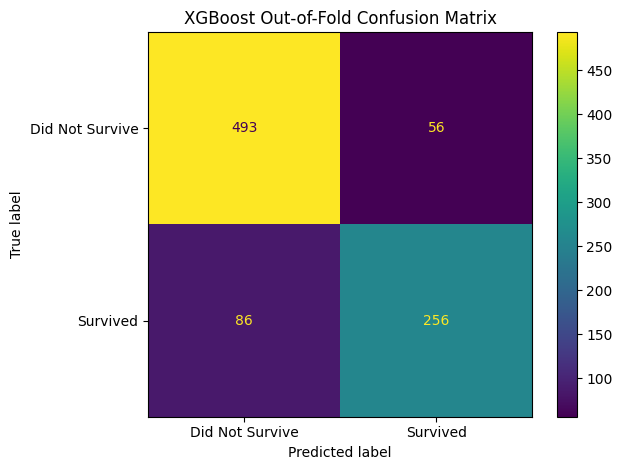

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y,
    oof_predictions,
    display_labels=["Did Not Survive", "Survived"],
    values_format="d"
)

plt.title("XGBoost Out-of-Fold Confusion Matrix")
plt.tight_layout()
plt.show()

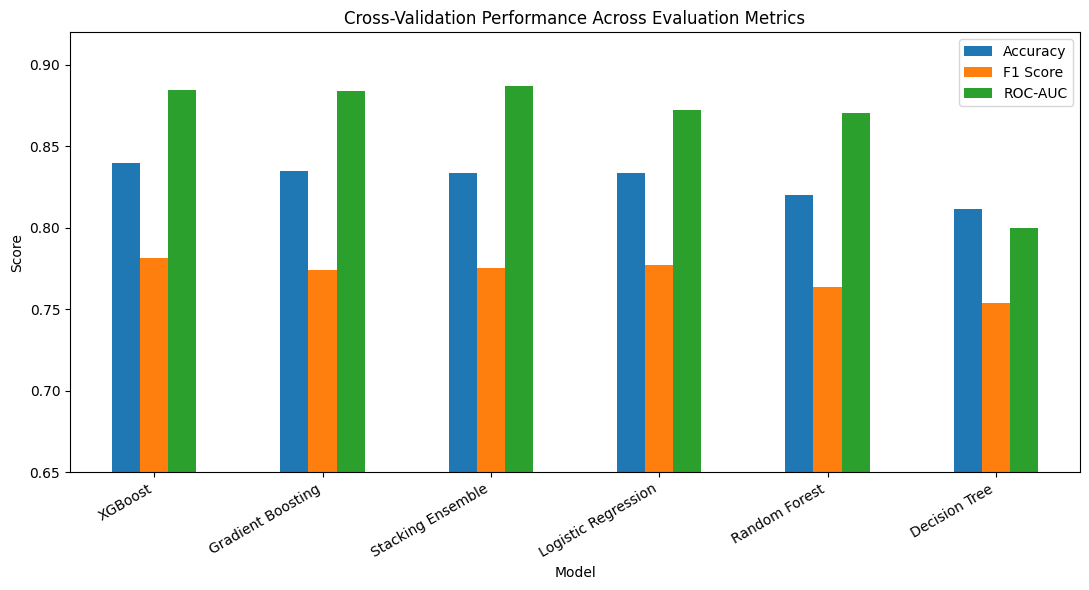

In [52]:
metrics_plot = model_results_v3.set_index("Model")[
    ["Accuracy Mean", "F1 Mean", "ROC-AUC Mean"]
]

metrics_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Cross-Validation Performance Across Evaluation Metrics")
plt.ylim(0.65, 0.92)
plt.xticks(rotation=30, ha="right")
plt.legend(
    ["Accuracy", "F1 Score", "ROC-AUC"]
)

plt.tight_layout()
plt.show()

## Hyperparameter Optimization

XGBoost achieved the highest mean cross-validation accuracy among the evaluated models. Therefore, hyperparameter optimization was performed using the strongest baseline feature set (V1). Randomized search with stratified cross-validation was used to explore multiple parameter combinations while controlling computational cost.

In [53]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_tuning = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=1
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb_tuning)
])

param_distributions = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [2, 3, 4, 5],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__gamma": [0, 0.1, 0.3],
    "classifier__reg_lambda": [1, 3, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

random_search.fit(X, y)

print("Best CV Accuracy:", round(random_search.best_score_, 4))
print("\nBest Parameters:")

for parameter, value in random_search.best_params_.items():
    print(parameter, ":", value)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV Accuracy: 0.8462

Best Parameters:
classifier__subsample : 0.9
classifier__reg_lambda : 3
classifier__n_estimators : 300
classifier__min_child_weight : 3
classifier__max_depth : 5
classifier__learning_rate : 0.05
classifier__gamma : 0.1
classifier__colsample_bytree : 0.8


In [54]:
original_xgb_accuracy = model_results.loc[
    model_results["Model"] == "XGBoost",
    "Accuracy Mean"
].iloc[0]

tuned_xgb_accuracy = random_search.best_score_

comparison = pd.DataFrame({
    "Model": [
        "Original XGBoost",
        "Tuned XGBoost"
    ],
    "Mean CV Accuracy": [
        original_xgb_accuracy,
        tuned_xgb_accuracy
    ]
})

comparison["Mean CV Accuracy"] = (
    comparison["Mean CV Accuracy"].round(4)
)

comparison

,Model,Mean CV Accuracy
0,Original XGBoost,0.8428
1,Tuned XGBoost,0.8462


In [55]:
best_index = random_search.best_index_

best_train_accuracy = (
    random_search.cv_results_["mean_train_score"][best_index]
)

best_cv_accuracy = (
    random_search.cv_results_["mean_test_score"][best_index]
)

overfitting_check = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Cross-Validation Accuracy",
        "Train-CV Gap"
    ],
    "Score": [
        best_train_accuracy,
        best_cv_accuracy,
        best_train_accuracy - best_cv_accuracy
    ]
})

overfitting_check["Score"] = (
    overfitting_check["Score"].round(4)
)

overfitting_check

,Metric,Score
0,Training Accuracy,0.9043
1,Cross-Validation Accuracy,0.8462
2,Train-CV Gap,0.0581


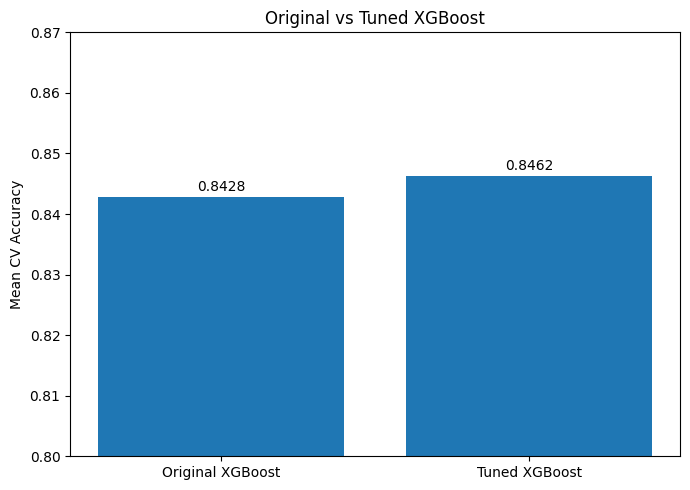

In [56]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    comparison["Model"],
    comparison["Mean CV Accuracy"]
)

plt.ylabel("Mean CV Accuracy")
plt.title("Original vs Tuned XGBoost")
plt.ylim(0.80, 0.87)

for bar, value in zip(
    bars,
    comparison["Mean CV Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.001,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Final Model and Kaggle Submission

Following model comparison and hyperparameter optimization, the tuned XGBoost pipeline was selected for the competition submission. The model achieved a mean 5-fold cross-validation accuracy of 0.8462, compared with 0.8428 for the original XGBoost configuration.

The selected pipeline was trained using the complete training dataset and used to generate survival predictions for the 418 passengers in the competition test set.

In [57]:
final_model = random_search.best_estimator_

test_predictions = final_model.predict(X_test)

print("Number of predictions:", len(test_predictions))

print("\nPrediction distribution:")
print(pd.Series(test_predictions).value_counts().sort_index())

Number of predictions: 418

Prediction distribution:
0    276
1    142
Name: count, dtype: int64


In [58]:
submission = pd.DataFrame({
    "PassengerId": test_model["PassengerId"],
    "Survived": test_predictions.astype(int)
})

print("Submission shape:", submission.shape)

print("\nMissing values:")
print(submission.isnull().sum())

print("\nUnique Survived values:")
print(submission["Survived"].unique())

print("\nFirst 10 rows:")
print(submission.head(10))

Submission shape: (418, 2)

Missing values:
PassengerId    0
Survived       0
dtype: int64

Unique Survived values:
[0 1]

First 10 rows:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0


In [59]:
assert len(submission) == 418
assert submission["PassengerId"].equals(test_model["PassengerId"])
assert submission["Survived"].isin([0, 1]).all()
assert submission.isnull().sum().sum() == 0

print("PASS: Submission format is correct.")

PASS: Submission format is correct.


In [60]:
submission.to_csv(
    "/kaggle/working/submission_tuned_xgboost.csv",
    index=False
)

print("Submission file saved successfully.")

Submission file saved successfully.


In [61]:
submission.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


## Conclusion

This project developed and evaluated multiple machine learning approaches for predicting passenger survival in the Titanic competition.

Exploratory analysis revealed substantial differences in survival patterns across passenger characteristics such as sex, passenger class, fare, family structure, cabin-information availability, and ticket-group size.

Six classification approaches were compared using 5-fold stratified cross-validation. XGBoost achieved the strongest baseline accuracy of 0.8428. Additional feature sets incorporating passenger Title and TicketGroupSize were also evaluated; however, they did not improve the highest cross-validation accuracy, demonstrating that additional features do not necessarily lead to better predictive performance.

Hyperparameter optimization further improved the XGBoost mean cross-validation accuracy from 0.8428 to 0.8462. The tuned model achieved a training accuracy of 0.9043, with a train–validation gap of 0.0581, indicating some degree of overfitting that should be considered when interpreting model performance.

The optimized XGBoost pipeline was subsequently trained on the available training data and used to generate predictions for all 418 passengers in the competition test set. The resulting submission contained 276 predicted non-survivors and 142 predicted survivors and passed all required format and missing-value validation checks.

Overall, the project demonstrates a structured competition workflow combining exploratory analysis, statistical analysis, feature engineering, cross-validation, model comparison, error analysis, hyperparameter optimization, and final prediction generation.

## Submission 2: Improved Validation and Feature Engineering

The first Kaggle submission achieved a leaderboard accuracy of 0.77033. To improve generalization, the second modeling stage uses a cleaner validation workflow in which preprocessing operations are learned within each cross-validation training fold.

Additional feature engineering will be evaluated systematically, and only features that improve cross-validation performance will be retained.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
# Reload the original Titanic datasets for Submission 2

train_v4 = pd.read_csv(
    "/kaggle/input/competitions/titanic/train.csv"
)

test_v4 = pd.read_csv(
    "/kaggle/input/competitions/titanic/test.csv"
)

print("Train shape:", train_v4.shape)
print("Test shape:", test_v4.shape)

Train shape: (891, 12)
Test shape: (418, 11)


In [64]:
for df in [train_v4, test_v4]:

    # Family size
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    # Traveling alone
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # Whether cabin information is available
    df["CabinKnown"] = df["Cabin"].notna().astype(int)

    # Extract passenger title from Name
    df["Title"] = (
        df["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )

    # Combine equivalent titles
    df["Title"] = df["Title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    # Group uncommon titles
    common_titles = ["Mr", "Miss", "Mrs", "Master"]

    df["Title"] = df["Title"].where(
        df["Title"].isin(common_titles),
        "Rare"
    )

print("Feature engineering completed.")

Feature engineering completed.


In [65]:
print("TRAIN MISSING VALUES")
print(train_v4.isnull().sum())

print("\nTEST MISSING VALUES")
print(test_v4.isnull().sum())

print("\nTRAIN TITLE COUNTS")
print(train_v4["Title"].value_counts())

print("\nTEST TITLE COUNTS")
print(test_v4["Title"].value_counts())

TRAIN MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
IsAlone          0
CabinKnown       0
Title            0
dtype: int64

TEST MISSING VALUES
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
FamilySize       0
IsAlone          0
CabinKnown       0
Title            0
dtype: int64

TRAIN TITLE COUNTS
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

TEST TITLE COUNTS
Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64


## Clean Preprocessing and Validation Pipeline

To reduce validation leakage, missing-value imputation and categorical encoding are performed inside the machine learning pipeline. This ensures that preprocessing parameters are learned only from the training portion of each cross-validation fold.

In [66]:
# Features for Submission 2 baseline

features_v4 = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
    "Title"
]

X_v4 = train_v4[features_v4].copy()
y_v4 = train_v4["Survived"].copy()

X_test_v4 = test_v4[features_v4].copy()

print("Training features shape:", X_v4.shape)
print("Target shape:", y_v4.shape)
print("Test features shape:", X_test_v4.shape)

Training features shape: (891, 11)
Target shape: (891,)
Test features shape: (418, 11)


In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numerical_features_v4 = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

categorical_features_v4 = [
    "Pclass",
    "Sex",
    "Embarked",
    "IsAlone",
    "CabinKnown",
    "Title"
]

numeric_transformer_v4 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_v4 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_v4 = ColumnTransformer([
    ("num", numeric_transformer_v4, numerical_features_v4),
    ("cat", categorical_transformer_v4, categorical_features_v4)
])

print("Clean preprocessing pipeline created successfully.")

Clean preprocessing pipeline created successfully.


## Model Comparison with Clean Cross-Validation

Multiple classification algorithms are evaluated using the improved preprocessing pipeline and 5-fold stratified cross-validation. Accuracy is used as the primary model-selection metric because it is the official evaluation metric of the Titanic competition. F1-score and ROC-AUC are also reported for additional performance analysis.

In [68]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier

# 5-fold stratified cross-validation
cv_v4 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Models
lr_v4 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

dt_v4 = DecisionTreeClassifier(
    random_state=42
)

rf_v4 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

gb_v4 = GradientBoostingClassifier(
    random_state=42
)

xgb_v4 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

models_v4 = {
    "Logistic Regression": lr_v4,
    "Decision Tree": dt_v4,
    "Random Forest": rf_v4,
    "Gradient Boosting": gb_v4,
    "XGBoost": xgb_v4
}

scoring_v4 = {
    "Accuracy": "accuracy",
    "F1": "f1",
    "ROC_AUC": "roc_auc"
}

In [69]:
results_v4 = []

for model_name, model in models_v4.items():

    pipeline_v4 = Pipeline([
        ("preprocessor", preprocessor_v4),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline_v4,
        X_v4,
        y_v4,
        cv=cv_v4,
        scoring=scoring_v4,
        n_jobs=-1
    )

    results_v4.append({
        "Model": model_name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Accuracy Std": scores["test_Accuracy"].std(),
        "F1": scores["test_F1"].mean(),
        "ROC_AUC": scores["test_ROC_AUC"].mean()
    })

results_v4_df = pd.DataFrame(results_v4)

results_v4_df = results_v4_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print(results_v4_df.round(4))

                 Model  Accuracy  Accuracy Std      F1  ROC_AUC
0    Gradient Boosting    0.8395        0.0205  0.7796   0.8760
1              XGBoost    0.8383        0.0261  0.7814   0.8739
2  Logistic Regression    0.8350        0.0118  0.7784   0.8727
3        Random Forest    0.8081        0.0167  0.7482   0.8691
4        Decision Tree    0.7755        0.0307  0.7155   0.7692


## Feature Experiment 1: Cabin Deck and Family Size Category

Additional Titanic-specific features are investigated to determine whether they improve generalization. The passenger's deck is extracted from the first letter of the Cabin variable, while FamilySize is converted into broader categories representing solo, small, medium, and large family groups.

In [70]:
# Extract cabin deck

for df in [train_v4, test_v4]:
    
    df["Deck"] = df["Cabin"].str[0]
    
    # Missing cabin information becomes Unknown
    df["Deck"] = df["Deck"].fillna("Unknown")

print("TRAIN DECK COUNTS")
print(train_v4["Deck"].value_counts())

print("\nTEST DECK COUNTS")
print(test_v4["Deck"].value_counts())

TRAIN DECK COUNTS
Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

TEST DECK COUNTS
Deck
Unknown    327
C           35
B           18
D           13
E            9
F            8
A            7
G            1
Name: count, dtype: int64


In [71]:
def family_category(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small"
    elif size <= 6:
        return "Medium"
    else:
        return "Large"


train_v4["FamilyCategory"] = (
    train_v4["FamilySize"].apply(family_category)
)

test_v4["FamilyCategory"] = (
    test_v4["FamilySize"].apply(family_category)
)

print("TRAIN FAMILY CATEGORIES")
print(train_v4["FamilyCategory"].value_counts())

print("\nTEST FAMILY CATEGORIES")
print(test_v4["FamilyCategory"].value_counts())

TRAIN FAMILY CATEGORIES
FamilyCategory
Alone     537
Small     292
Medium     37
Large      25
Name: count, dtype: int64

TEST FAMILY CATEGORIES
FamilyCategory
Alone     253
Small     145
Medium     10
Large      10
Name: count, dtype: int64


In [72]:
deck_survival = (
    train_v4
    .groupby("Deck")["Survived"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

deck_survival["Survival Rate (%)"] = (
    deck_survival["mean"] * 100
).round(2)

print("SURVIVAL BY DECK")
print(deck_survival[["count", "Survival Rate (%)"]])


family_survival = (
    train_v4
    .groupby("FamilyCategory")["Survived"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

family_survival["Survival Rate (%)"] = (
    family_survival["mean"] * 100
).round(2)

print("\nSURVIVAL BY FAMILY CATEGORY")
print(family_survival[["count", "Survival Rate (%)"]])

SURVIVAL BY DECK
         count  Survival Rate (%)
Deck                             
D           33              75.76
E           32              75.00
B           47              74.47
F           13              61.54
C           59              59.32
G            4              50.00
A           15              46.67
Unknown    687              29.99
T            1               0.00

SURVIVAL BY FAMILY CATEGORY
                count  Survival Rate (%)
FamilyCategory                          
Small             292              57.88
Alone             537              30.35
Medium             37              16.22
Large              25              16.00


## V5: Deck and Family Category Features

A new feature set is evaluated by adding Cabin Deck and FamilyCategory to the clean V4 feature set. The same cross-validation strategy is maintained to ensure a fair comparison with the previous experiment.

In [73]:
features_v5 = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
    "Title",
    "Deck",
    "FamilyCategory"
]

X_v5 = train_v4[features_v5].copy()
y_v5 = train_v4["Survived"].copy()

X_test_v5 = test_v4[features_v5].copy()

print("V5 Training shape:", X_v5.shape)
print("V5 Test shape:", X_test_v5.shape)

V5 Training shape: (891, 13)
V5 Test shape: (418, 13)


In [74]:
numerical_features_v5 = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

categorical_features_v5 = [
    "Pclass",
    "Sex",
    "Embarked",
    "IsAlone",
    "CabinKnown",
    "Title",
    "Deck",
    "FamilyCategory"
]

numeric_transformer_v5 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_v5 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_v5 = ColumnTransformer([
    ("num", numeric_transformer_v5, numerical_features_v5),
    ("cat", categorical_transformer_v5, categorical_features_v5)
])

print("V5 preprocessing pipeline created successfully.")

V5 preprocessing pipeline created successfully.


In [75]:
results_v5 = []

for model_name, model in models_v4.items():

    pipeline_v5 = Pipeline([
        ("preprocessor", preprocessor_v5),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline_v5,
        X_v5,
        y_v5,
        cv=cv_v4,
        scoring=scoring_v4,
        n_jobs=-1
    )

    results_v5.append({
        "Model": model_name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Accuracy Std": scores["test_Accuracy"].std(),
        "F1": scores["test_F1"].mean(),
        "ROC_AUC": scores["test_ROC_AUC"].mean()
    })

results_v5_df = pd.DataFrame(results_v5)

results_v5_df = results_v5_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print(results_v5_df.round(4))

                 Model  Accuracy  Accuracy Std      F1  ROC_AUC
0    Gradient Boosting    0.8440        0.0230  0.7862   0.8771
1              XGBoost    0.8395        0.0281  0.7802   0.8778
2  Logistic Regression    0.8305        0.0141  0.7756   0.8761
3        Random Forest    0.8047        0.0217  0.7445   0.8664
4        Decision Tree    0.7856        0.0265  0.7242   0.7759


## Feature Experiment 2: Fare Per Person

FarePerPerson is introduced to represent the passenger's fare relative to their family size. The feature is evaluated using the same cross-validation strategy to determine whether it provides additional predictive information beyond the V5 feature set.

In [76]:
# Create FarePerPerson

for df in [train_v4, test_v4]:
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

print("TRAIN FARE PER PERSON")
print(train_v4["FarePerPerson"].describe())

print("\nTEST FARE PER PERSON")
print(test_v4["FarePerPerson"].describe())

print("\nMissing values:")
print("Train:", train_v4["FarePerPerson"].isnull().sum())
print("Test:", test_v4["FarePerPerson"].isnull().sum())

TRAIN FARE PER PERSON
count    891.000000
mean      19.916375
std       35.841257
min        0.000000
25%        7.250000
50%        8.300000
75%       23.666667
max      512.329200
Name: FarePerPerson, dtype: float64

TEST FARE PER PERSON
count    417.000000
mean      21.804161
std       35.639766
min        0.000000
25%        7.629200
50%        8.662500
75%       26.000000
max      262.375000
Name: FarePerPerson, dtype: float64

Missing values:
Train: 0
Test: 1


## V6: Fare Per Person Feature

The V5 feature set is extended with FarePerPerson. The same preprocessing and cross-validation strategy is maintained to determine whether this additional feature improves predictive performance.

In [77]:
features_v6 = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
    "Title",
    "Deck",
    "FamilyCategory",
    "FarePerPerson"
]

X_v6 = train_v4[features_v6].copy()
y_v6 = train_v4["Survived"].copy()

X_test_v6 = test_v4[features_v6].copy()

print("V6 Training shape:", X_v6.shape)
print("V6 Test shape:", X_test_v6.shape)

V6 Training shape: (891, 14)
V6 Test shape: (418, 14)


In [78]:
numerical_features_v6 = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "FarePerPerson"
]

categorical_features_v6 = [
    "Pclass",
    "Sex",
    "Embarked",
    "IsAlone",
    "CabinKnown",
    "Title",
    "Deck",
    "FamilyCategory"
]

numeric_transformer_v6 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_v6 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_v6 = ColumnTransformer([
    ("num", numeric_transformer_v6, numerical_features_v6),
    ("cat", categorical_transformer_v6, categorical_features_v6)
])

print("V6 preprocessing pipeline created successfully.")

V6 preprocessing pipeline created successfully.


In [79]:
results_v6 = []

for model_name, model in models_v4.items():

    pipeline_v6 = Pipeline([
        ("preprocessor", preprocessor_v6),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline_v6,
        X_v6,
        y_v6,
        cv=cv_v4,
        scoring=scoring_v4,
        n_jobs=-1
    )

    results_v6.append({
        "Model": model_name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Accuracy Std": scores["test_Accuracy"].std(),
        "F1": scores["test_F1"].mean(),
        "ROC_AUC": scores["test_ROC_AUC"].mean()
    })

results_v6_df = pd.DataFrame(results_v6)

results_v6_df = results_v6_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print(results_v6_df.round(4))

                 Model  Accuracy  Accuracy Std      F1  ROC_AUC
0    Gradient Boosting    0.8384        0.0201  0.7828   0.8832
1  Logistic Regression    0.8294        0.0147  0.7751   0.8751
2              XGBoost    0.8282        0.0223  0.7699   0.8796
3        Random Forest    0.8024        0.0319  0.7399   0.8717
4        Decision Tree    0.7901        0.0249  0.7288   0.7794


## Feature Experiment 3: Passenger Age Groups

Passenger age is converted into categorical life-stage groups to investigate whether survival patterns are better represented by age ranges than by the continuous Age variable alone. Missing ages are retained as an Unknown category to avoid performing imputation outside the cross-validation pipeline.

In [80]:
def create_age_group(age):
    if pd.isna(age):
        return "Unknown"
    elif age < 13:
        return "Child"
    elif age < 18:
        return "Teen"
    elif age < 30:
        return "YoungAdult"
    elif age < 50:
        return "Adult"
    else:
        return "Senior"


train_v4["AgeGroup"] = train_v4["Age"].apply(create_age_group)
test_v4["AgeGroup"] = test_v4["Age"].apply(create_age_group)

print("TRAIN AGE GROUPS")
print(train_v4["AgeGroup"].value_counts())

print("\nTEST AGE GROUPS")
print(test_v4["AgeGroup"].value_counts())

TRAIN AGE GROUPS
AgeGroup
YoungAdult    271
Adult         256
Unknown       177
Senior         74
Child          69
Teen           44
Name: count, dtype: int64

TEST AGE GROUPS
AgeGroup
YoungAdult    144
Adult         111
Unknown        86
Senior         36
Child          25
Teen           16
Name: count, dtype: int64


In [81]:
age_group_survival = (
    train_v4
    .groupby("AgeGroup")["Survived"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

age_group_survival["Survival Rate (%)"] = (
    age_group_survival["mean"] * 100
).round(2)

print(age_group_survival[[
    "count",
    "Survival Rate (%)"
]])

            count  Survival Rate (%)
AgeGroup                            
Child          69              57.97
Teen           44              47.73
Adult         256              41.80
Senior         74              36.49
YoungAdult    271              35.06
Unknown       177              29.38


## V7: Age Group Feature

The V5 feature set is extended with AgeGroup to determine whether categorical life-stage information provides additional predictive value. FarePerPerson is excluded because the previous experiment reduced cross-validation accuracy.

In [82]:
features_v7 = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
    "Title",
    "Deck",
    "FamilyCategory",
    "AgeGroup"
]

X_v7 = train_v4[features_v7].copy()
y_v7 = train_v4["Survived"].copy()

X_test_v7 = test_v4[features_v7].copy()

print("V7 Training shape:", X_v7.shape)
print("V7 Test shape:", X_test_v7.shape)

V7 Training shape: (891, 14)
V7 Test shape: (418, 14)


In [83]:
numerical_features_v7 = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

categorical_features_v7 = [
    "Pclass",
    "Sex",
    "Embarked",
    "IsAlone",
    "CabinKnown",
    "Title",
    "Deck",
    "FamilyCategory",
    "AgeGroup"
]

numeric_transformer_v7 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_v7 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_v7 = ColumnTransformer([
    ("num", numeric_transformer_v7, numerical_features_v7),
    ("cat", categorical_transformer_v7, categorical_features_v7)
])

print("V7 preprocessing pipeline created successfully.")

V7 preprocessing pipeline created successfully.


In [84]:
results_v7 = []

for model_name, model in models_v4.items():

    pipeline_v7 = Pipeline([
        ("preprocessor", preprocessor_v7),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline_v7,
        X_v7,
        y_v7,
        cv=cv_v4,
        scoring=scoring_v4,
        n_jobs=-1
    )

    results_v7.append({
        "Model": model_name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Accuracy Std": scores["test_Accuracy"].std(),
        "F1": scores["test_F1"].mean(),
        "ROC_AUC": scores["test_ROC_AUC"].mean()
    })

results_v7_df = pd.DataFrame(results_v7)

results_v7_df = results_v7_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print(results_v7_df.round(4))

                 Model  Accuracy  Accuracy Std      F1  ROC_AUC
0    Gradient Boosting    0.8383        0.0217  0.7790   0.8806
1              XGBoost    0.8361        0.0300  0.7772   0.8775
2  Logistic Regression    0.8271        0.0154  0.7709   0.8728
3        Random Forest    0.8069        0.0182  0.7426   0.8699
4        Decision Tree    0.7935        0.0330  0.7322   0.7793


## Hyperparameter Optimization of V5 Gradient Boosting

Gradient Boosting achieved the highest cross-validation accuracy using the V5 feature set. Therefore, hyperparameter optimization is performed on this model while retaining the V5 features and leakage-safe preprocessing pipeline.

In [85]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb_tuning = GradientBoostingClassifier(
    random_state=42
)

gb_pipeline_v5 = Pipeline([
    ("preprocessor", preprocessor_v5),
    ("classifier", gb_tuning)
])

param_distributions_gb = {
    "classifier__n_estimators": [50, 100, 150, 200, 300],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__max_depth": [1, 2, 3, 4],
    "classifier__min_samples_split": [2, 5, 10, 15],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__max_features": [None, "sqrt", "log2"]
}

gb_random_search = RandomizedSearchCV(
    estimator=gb_pipeline_v5,
    param_distributions=param_distributions_gb,
    n_iter=50,
    scoring="accuracy",
    cv=cv_v4,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gb_random_search.fit(X_v5, y_v5)

print("\nBest CV Accuracy:")
print(round(gb_random_search.best_score_, 4))

print("\nBest Parameters:")
for parameter, value in gb_random_search.best_params_.items():
    print(parameter, ":", value)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV Accuracy:
0.8451

Best Parameters:
classifier__subsample : 1.0
classifier__n_estimators : 50
classifier__min_samples_split : 5
classifier__min_samples_leaf : 1
classifier__max_features : None
classifier__max_depth : 4
classifier__learning_rate : 0.1


### Overfitting Assessment

The optimized Gradient Boosting model is evaluated on the full training data and compared with its cross-validation accuracy. The difference between training and validation performance provides an indication of potential overfitting.

In [86]:
from sklearn.metrics import accuracy_score

# Best tuned Gradient Boosting pipeline
best_gb_v5 = gb_random_search.best_estimator_

# Training predictions
train_predictions_gb = best_gb_v5.predict(X_v5)

# Training accuracy
train_accuracy_gb = accuracy_score(
    y_v5,
    train_predictions_gb
)

# Best CV accuracy
cv_accuracy_gb = gb_random_search.best_score_

# Gap
accuracy_gap_gb = train_accuracy_gb - cv_accuracy_gb

print("Training Accuracy:", round(train_accuracy_gb, 4))
print("CV Accuracy:", round(cv_accuracy_gb, 4))
print("Train-CV Gap:", round(accuracy_gap_gb, 4))

Training Accuracy: 0.9057
CV Accuracy: 0.8451
Train-CV Gap: 0.0606


In [87]:
# Generate Submission 2 predictions

submission2_predictions = best_gb_v5.predict(X_test_v5)

print("Number of predictions:", len(submission2_predictions))

print("\nPrediction distribution:")
print(
    pd.Series(submission2_predictions)
    .value_counts()
    .sort_index()
)

Number of predictions: 418

Prediction distribution:
0    268
1    150
Name: count, dtype: int64


In [88]:
submission2 = pd.DataFrame({
    "PassengerId": test_v4["PassengerId"],
    "Survived": submission2_predictions.astype(int)
})

print(submission2.head())
print("\nSubmission shape:", submission2.shape)
print("\nMissing values:")
print(submission2.isnull().sum())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

Submission shape: (418, 2)

Missing values:
PassengerId    0
Survived       0
dtype: int64


In [89]:
assert len(submission2) == 418
assert submission2["PassengerId"].equals(test_v4["PassengerId"])
assert submission2["Survived"].isin([0, 1]).all()
assert submission2.isnull().sum().sum() == 0

print("Submission 2 passed all validation checks.")

Submission 2 passed all validation checks.


In [90]:
submission2.to_csv(
    "/kaggle/working/submission2_gradient_boosting.csv",
    index=False
)

print("Submission 2 saved successfully.")

Submission 2 saved successfully.


In [91]:
check_submission2 = pd.read_csv(
    "/kaggle/working/submission2_gradient_boosting.csv"
)

print(check_submission2.head())
print("\nShape:", check_submission2.shape)
print("\nPrediction distribution:")
print(check_submission2["Survived"].value_counts().sort_index())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

Shape: (418, 2)

Prediction distribution:
Survived
0    268
1    150
Name: count, dtype: int64
